In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pymannkendall as mk
from google.cloud import bigquery
from google.oauth2 import service_account

KEYFILE = r"C:\Users\sansk\Documents\Spring-26\gcp_secret_service\damagereport-499916-f3d6c433577c.json"
PROJECT = "damagereport-499916"

creds = service_account.Credentials.from_service_account_file(
    KEYFILE,
    scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
client = bigquery.Client(project=PROJECT, credentials=creds)

print("Connection successful")

Connection successful


In [2]:
query = """
    SELECT
        event_year,
        SUM(event_count)                                              AS total_events,
        SAFE_DIVIDE(SUM(total_damage_2024_usd), SUM(event_count))    AS avg_damage_per_event
    FROM `damagereport-499916.dbt_marts.mart_severity_trends`
    GROUP BY event_year
    ORDER BY event_year
"""

df = client.query(query).result().to_dataframe()
print(f"Years: {df['event_year'].min()} – {df['event_year'].max()}")
print(f"Rows: {len(df)}")
df.head()

C:\Users\sansk\Documents\Spring-26\DamageReport\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Years: 1996 – 2025
Rows: 30


,event_year,total_events,avg_damage_per_event
0,1996,48534,319775.254208
1,1997,41991,488841.275827
2,1998,50973,607285.824717
3,1999,46383,497394.426091
4,2000,52007,313512.791581


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_year            30 non-null     Int64  
 1   total_events          30 non-null     Int64  
 2   avg_damage_per_event  30 non-null     float64
dtypes: Int64(2), float64(1)
memory usage: 912.0 bytes


In [4]:
df.describe()

,event_year,total_events,avg_damage_per_event
count,30.0,30.0,3.000000e+01
mean,2010.5,59357.666667,5.216544e+05
std,8.803408,9009.604118,5.758824e+05
min,1996.0,41991.0,6.424961e+04
25%,2003.25,52545.75,2.602043e+05
50%,2010.5,58459.0,3.507899e+05
75%,2017.75,64079.5,5.294562e+05
max,2025.0,79091.0,2.995763e+06


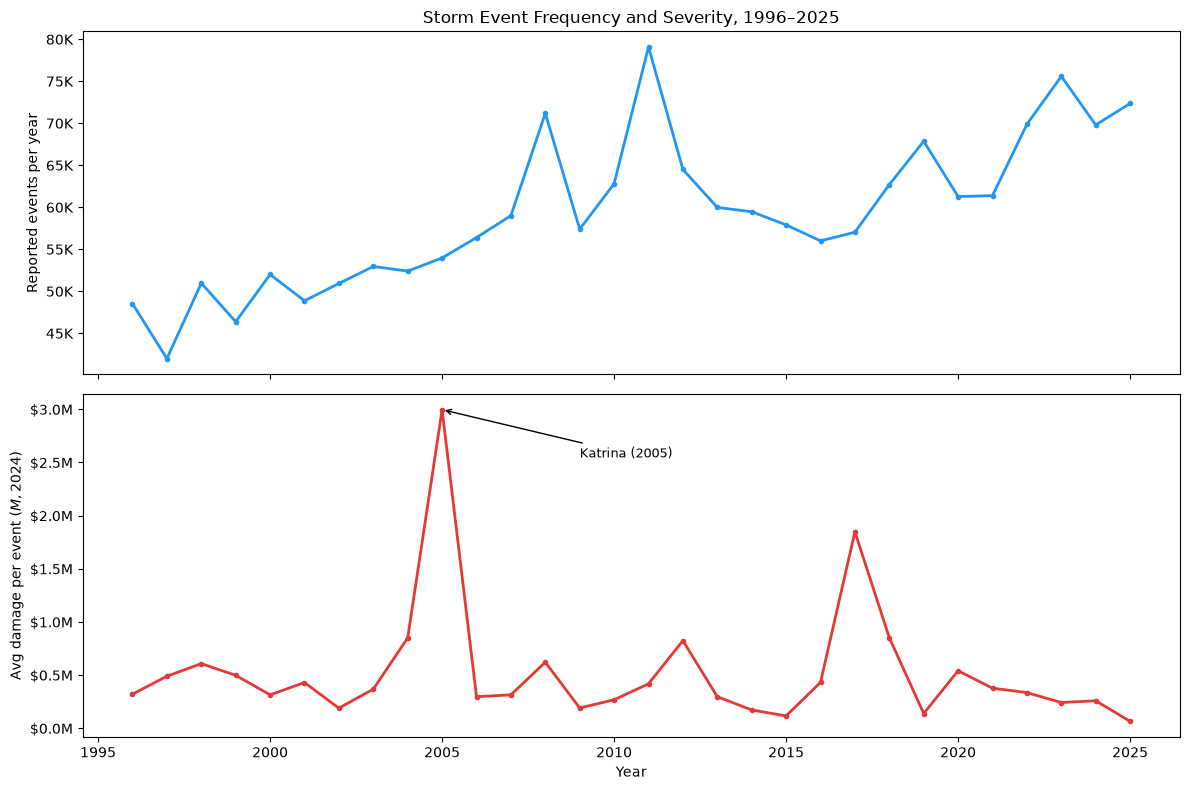

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


ax1.plot(df['event_year'], df['total_events'], color='#2196F3', linewidth=2, marker='o', markersize=3)
ax1.set_ylabel('Reported events per year')
ax1.set_title('Storm Event Frequency and Severity, 1996–2025')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))


ax2.plot(df['event_year'], df['avg_damage_per_event'] / 1e6, color='#E53935', linewidth=2, marker='o', markersize=3)
ax2.set_ylabel('Avg damage per event ($M, 2024 $)')
ax2.set_xlabel('Year')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

# Annotate Katrina
katrina_val = df.loc[df['event_year'] == 2005, 'avg_damage_per_event'].values[0] / 1e6
ax2.annotate('Katrina (2005)', xy=(2005, katrina_val), xytext=(2009, katrina_val * 0.85),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
result_freq = mk.original_test(df['total_events'])
result_sev  = mk.original_test(df['avg_damage_per_event'])

print("=== Frequency (event count per year) ===")
print(f"  Trend:     {result_freq.trend}")
print(f"  p-value:   {result_freq.p:.4f}")
print(f"  Tau:       {result_freq.Tau:.3f}  (direction & strength, -1 to +1)")
print(f"  Slope:     {result_freq.slope:,.0f} events/year (Sen's slope)")

print("\n=== Severity (avg damage per event) ===")
print(f"  Trend:     {result_sev.trend}")
print(f"  p-value:   {result_sev.p:.4f}")
print(f"  Tau:       {result_sev.Tau:.3f}")
print(f"  Slope:     ${result_sev.slope:,.0f}/year (Sen's slope)")

=== Frequency (event count per year) ===
  Trend:     increasing
  p-value:   0.0000
  Tau:       0.655  (direction & strength, -1 to +1)
  Slope:     813 events/year (Sen's slope)

=== Severity (avg damage per event) ===
  Trend:     no trend
  p-value:   0.1340
  Tau:       -0.195
  Slope:     $-6,278/year (Sen's slope)


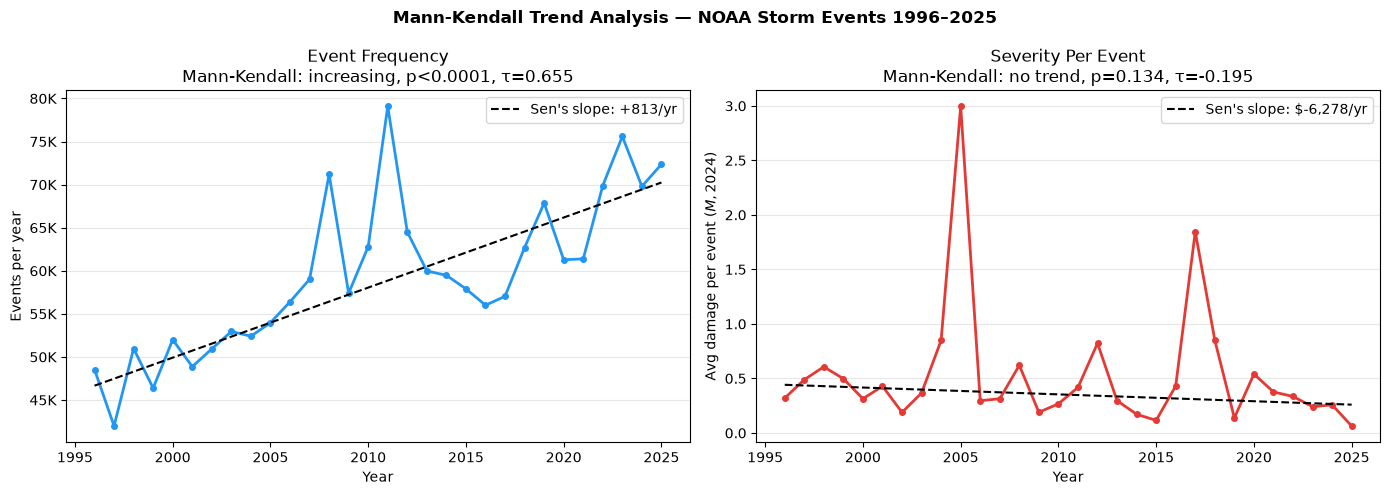

In [8]:
from scipy.stats import theilslopes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

years = df['event_year'].astype(float)

# Frequency with Sen's slope line
slope_f, intercept_f, _, _ = theilslopes(df['total_events'], years)
ax1.plot(years, df['total_events'], color='#2196F3', linewidth=2, marker='o', markersize=4)
ax1.plot(years, intercept_f + slope_f * years, color='black', linewidth=1.5,
         linestyle='--', label=f"Sen's slope: +{slope_f:,.0f}/yr")
ax1.set_title(f'Event Frequency\nMann-Kendall: increasing, p<0.0001, τ=0.655')
ax1.set_ylabel('Events per year')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax1.legend()

# Severity with Sen's slope line
slope_s, intercept_s, _, _ = theilslopes(df['avg_damage_per_event'], years)
ax2.plot(years, df['avg_damage_per_event'] / 1e6, color='#E53935', linewidth=2, marker='o', markersize=4)
ax2.plot(years, (intercept_s + slope_s * years) / 1e6, color='black', linewidth=1.5,
         linestyle='--', label=f"Sen's slope: ${slope_s:,.0f}/yr")
ax2.set_title(f'Severity Per Event\nMann-Kendall: no trend, p=0.134, τ=-0.195')
ax2.set_ylabel('Avg damage per event ($M, 2024 $)')
ax2.legend()

for ax in (ax1, ax2):
    ax.set_xlabel('Year')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Mann-Kendall Trend Analysis — NOAA Storm Events 1996–2025', fontweight='bold')
plt.tight_layout()
plt.show()